In [24]:
import numpy as np
from scipy import stats as st
from scipy import special as sp
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap, to_rgba
import seaborn as sns
import pandas as pd
import os
import json
import decimal
from itertools import product
from scipy import ndimage


In [2]:
root_dir = '../simulations'
params_path = os.path.join(root_dir, 'map_params.json')
params = json.load(open(params_path))

# Read map parameters.
eps = params['eps']
alpha = params['alpha']
ps = {1: params['p1'], 2: params['p2']} # misclassification rates
Ns = {1: params['N1dot']*params['px_per_km2'], 2: params['N2dot']*params['px_per_km2']} # mapped areas (pixels)

In [21]:
red = '#ff0000'
cyan = '#00eeee'
grey = "#808080"
dark = "#07051b"
sns.set_style('darkgrid')

# 2. $\text{Pr}[d(N_{\bullet 1}, \text{CI}) > \delta|]$

### Setup

In [4]:
max_delta = .5
max_n = 1000
n_deltas = 200
n_ns = 200

deltas = np.linspace(0, max_delta, num=n_deltas+1)
ns = np.linspace(0, max_n, num=n_ns+1)[1:].astype(int)

In [5]:
P_COL = 'population proportion'
N_COL = 'sample size'
PROB_COL = 'probability of zero false negatives'

### Calculate $\text{Pr}(d(N_{\bullet 1}, \text{CI}) > \delta|)$ for each $\delta, n$

In [6]:
%%time
annot = False

deltas = np.linspace(0, max_delta, num=n_deltas+1)
ns = np.linspace(0, max_n, num=n_ns+1)[1:].astype(int)

N = sum(Ns.values())
N_dot1 = Ns[1]*(1-ps[1]) + Ns[2]*ps[2]
z = st.norm.ppf(1 - alpha/2)

n_combs = dict()
probs = []
for i, delta in enumerate(deltas):
    print(i, delta)
    probs.append([])
    for n in ns:
        n2 = int(np.round((n-2) / (1 + Ns[1]/Ns[2]*(ps[1]*(1-ps[1])/ps[2]/(1-ps[2]))**.5))) + 1
        n1 = n - n2

        Pr = 0
        for x1, x2 in product(range(n1+1), range(n2+1)):
            N_dot1_hat = Ns[1]*(1-x1/n1)+Ns[2]*x2/n2
            std = (Ns[1]**2*x1*(n1-x1)/n1**3 + Ns[2]**2*x2*(n2-x2)/n2**3)**.5
            # If the distance of N_dot1 to CI is greater than delta...
            if N_dot1 + delta*N_dot1 < N_dot1_hat - z*std or N_dot1 - delta*N_dot1 > N_dot1_hat + z*std:
                small_x1 = min(x1, n1 - x1)
                try:
                    n_comb1 = n_combs[n1, small_x1]
                except KeyError:
                    n_comb1 = decimal.Decimal(sp.comb(n1, small_x1, exact=True))
                    n_combs[n1, small_x1] = n_comb1
                small_x2 = min(x2, n2 - x2)
                try:
                    n_comb2 = n_combs[n2, small_x2]
                except KeyError:
                    n_comb2 = decimal.Decimal(sp.comb(n2, small_x2, exact=True))
                    n_combs[n2, small_x2] = n_comb2
                Pr += n_comb1*decimal.Decimal(ps[1]**x1*(1-ps[1])**(n1-x1))*\
                    n_comb2*decimal.Decimal(ps[2]**x2*(1-ps[2])**(n2-x2))

        assert 0 <= Pr <= 1
        probs[-1].append(float(Pr))


0 0.0
1 0.0025
2 0.005
3 0.0075
4 0.01
5 0.0125
6 0.015
7 0.0175
8 0.02
9 0.0225
10 0.025
11 0.0275
12 0.03
13 0.0325
14 0.035
15 0.0375
16 0.04
17 0.0425
18 0.045
19 0.0475
20 0.05
21 0.0525
22 0.055
23 0.0575
24 0.06
25 0.0625
26 0.065
27 0.0675
28 0.07
29 0.0725
30 0.075
31 0.0775
32 0.08
33 0.0825
34 0.085
35 0.08750000000000001
36 0.09
37 0.0925
38 0.095
39 0.0975
40 0.1
41 0.10250000000000001
42 0.105
43 0.1075
44 0.11
45 0.1125
46 0.115
47 0.11750000000000001
48 0.12
49 0.1225
50 0.125
51 0.1275
52 0.13
53 0.1325
54 0.135
55 0.1375
56 0.14
57 0.14250000000000002
58 0.145
59 0.1475
60 0.15
61 0.1525
62 0.155
63 0.1575
64 0.16
65 0.1625
66 0.165
67 0.1675
68 0.17
69 0.17250000000000001
70 0.17500000000000002
71 0.1775
72 0.18
73 0.1825
74 0.185
75 0.1875
76 0.19
77 0.1925
78 0.195
79 0.1975
80 0.2
81 0.2025
82 0.20500000000000002
83 0.20750000000000002
84 0.21
85 0.2125
86 0.215
87 0.2175
88 0.22
89 0.2225
90 0.225
91 0.2275
92 0.23
93 0.2325
94 0.23500000000000001
95 0.2375000000

### Plot

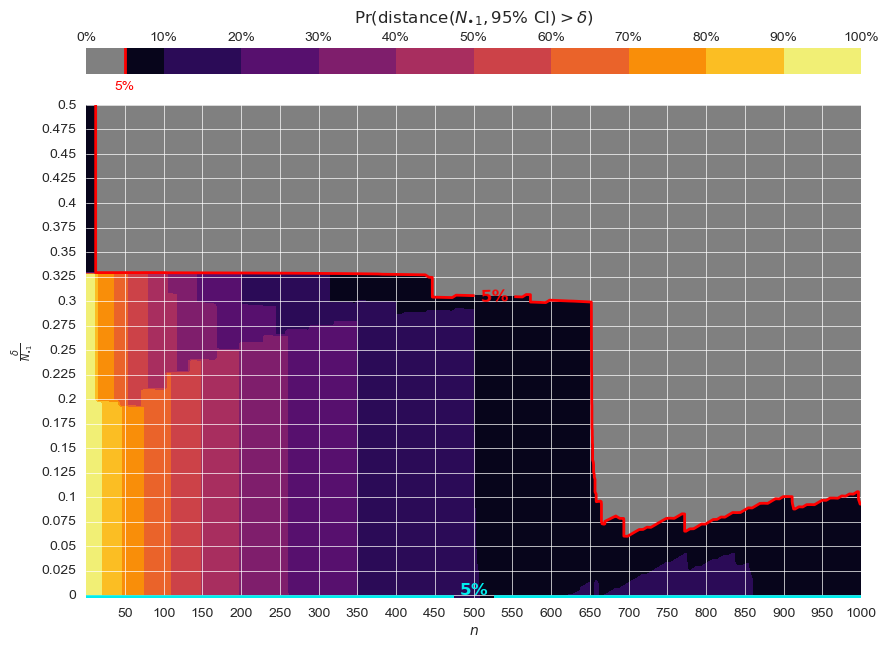

In [25]:
df = pd.DataFrame(probs)
df.columns = ns
df.set_index(deltas)

make_labels = np.vectorize(lambda x: x[0] if x.endswith('.0') else x[1:])
prob_labels = make_labels(np.round(probs, 2).astype(str)) if annot else False

n_ylabels = 20
n_xlabels = 20
n_contours = 11
annot = False

fig, ax = plt.subplots(figsize=(10,8))

color_levels = [0, .05] + list(np.linspace(.1, 1, n_contours - 1))

n_bands = len(color_levels) - 1
# Compute each band’s midpoint, normalized to [0,1]
lo, hi = color_levels[0], color_levels[-1]
mid_norm = [
    (0.5 * (color_levels[i] + color_levels[i + 1]) - lo) / (hi - lo)
    for i in range(n_bands)
]
# Sample Inferno at those midpoints
base_colors = plt.cm.inferno(np.array(mid_norm))
# Replace the first bands' colors
base_colors[0] = to_rgba(grey)
base_colors[1] = to_rgba(dark)
# Build a ListedColormap of length 11
my_inferno = ListedColormap(base_colors)

# BoundaryNorm to map each [levels[i], levels[i+1]) → color index i
norm = BoundaryNorm(color_levels, ncolors=n_bands)

# Contours
smooth_scale = 1
z = ndimage.zoom(df.to_numpy(), smooth_scale)
cntrs = ax.contourf(np.linspace(0, len(df.columns), len(df.columns) * smooth_scale),
                   np.linspace(0, len(df.index), len(df.index) * smooth_scale),
                   z, levels=color_levels, cmap=my_inferno, norm=norm)

# Heatmap
ax = sns.heatmap(df, annot=prob_labels, linewidths=0, fmt = '', vmin=0, vmax=1, ax=ax, alpha=0,
                 cbar=False)
x_ticks = np.arange(n_ns)[n_ns // n_xlabels - 1::n_ns // n_xlabels] + 1
ax.set_xticks(x_ticks)
ax.set_xticklabels(ns[n_ns // n_xlabels - 1::n_ns // n_xlabels], rotation=0)
if n_xlabels < n_ns:
    ax.xaxis.set_ticks_position('none')
for x in x_ticks:
    ax.axvline(x, color='w', lw=.5)

y_ticks = np.arange(n_deltas + 1)[::n_deltas // n_ylabels] + 1
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{delta:.3g}' for delta in deltas[y_ticks-1]], rotation=0)
if n_ylabels < n_deltas:
    ax.yaxis.set_ticks_position('none')
for y in y_ticks:
    ax.axhline(y, color='w', lw=.5)

ax.set_xlabel('$n$')
ax.set_ylabel(r'$\delta$ as proportion of $N_{\bullet 1}$')
ax.set_ylabel(r'$\frac{\delta}{N_{\bullet 1}}$')

cbar = plt.colorbar(cntrs, ax=ax, orientation='horizontal', location='top',
                    aspect=30, spacing='proportional')
cbar.set_ticks(color_levels)
cbar.set_ticklabels([f'{prob:.0%}' if prob != .05 else '' for prob in color_levels])
cbar.ax.tick_params(length=0)
cbar.ax.axvline(.05, color='red', lw=2)
plt.setp(cbar.ax.spines.values(), visible=False) 
cbar.ax.set_title(r'$\mathrm{Pr}(\text{distance}({N}_{\bullet 1}, \text{95\% CI}) > \delta)$')
for label in cbar.ax.get_xticklabels():
    if label.get_text() == '5%':
        label.set_color('red')
cbar.ax.text(
    .05, -.25, '5%', transform=cbar.ax.transAxes,
    ha='center', va='top', color='red'
)

# 5% contour
cntr = ax.contour(np.linspace(0, len(df.columns), len(df.columns) * smooth_scale),
                   np.linspace(0, len(df.index), len(df.index) * smooth_scale),
                   z, [0.05], colors='red', linewidths=2)
texts = ax.clabel(cntr, inline=True, fmt=lambda x: r'$\bf 5\%$', fontsize=12, manual=[(105, 105)])

# Draw cyan horizontal "contour"
x = np.linspace(0, len(df.columns), len(df.columns) * smooth_scale)
y = np.linspace(0, len(df.index), len(df.index) * smooth_scale)
X, Y = np.meshgrid(x, y)
Z = Y
horiz_cntr = ax.contour(X, Y, Z, levels=[0], colors=cyan, linewidths=4)
texts = ax.clabel(horiz_cntr, inline=True, fmt=lambda x: r'$\bf 5\%$', fontsize=12, manual=[(100, 100)])
for txt in texts:
    txt.set_verticalalignment('bottom')

plt.gca().invert_yaxis()

plt.savefig(f'2_Pr(distance_to_CI).png', bbox_inches='tight', dpi=600)